<a href="https://colab.research.google.com/github/TusharB-07/regime-aware-stock-prediction/blob/main/Experiment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [7]:
pip install tenacity -q

In [8]:
from tenacity import retry, stop_after_attempt, wait_fixed

@retry(stop=stop_after_attempt(3), wait=wait_fixed(5))
def download_data_with_retries(ticker, start, end, auto_adjust):
    print(f"Attempting to download data for {ticker}...")
    data = yf.download(ticker, start=start, end=end, auto_adjust=auto_adjust)
    if data.empty:
        raise Exception("Downloaded data is empty, retrying...")
    return data

In [9]:
ticker = "SPY"
data = download_data_with_retries(ticker, start="2010-01-01", end="2026-01-01", auto_adjust=True)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print(f"Shape: {data.shape}")
display(data.head())

Attempting to download data for SPY...


[*********************100%***********************]  1 of 1 completed

Shape: (4024, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,84.578484,84.623260,83.220213,83.862034,118944600
2010-01-05,84.802361,84.839678,84.220245,84.526232,111579900
2010-01-06,84.862083,85.071047,84.653120,84.720284,116074400
2010-01-07,85.220306,85.324788,84.466539,84.705356,131091100
2010-01-08,85.503899,85.541216,84.824766,84.996413,126402800


In [10]:
ticker = "SPY"
data = yf.download(ticker, start="2010-01-01", end="2026-01-01", auto_adjust=True)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print(f"Shape: {data.shape}")
data.head()

[*********************100%***********************]  1 of 1 completed

Shape: (4024, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,84.578484,84.623260,83.220213,83.862034,118944600
2010-01-05,84.802361,84.839678,84.220245,84.526232,111579900
2010-01-06,84.862083,85.071047,84.653120,84.720284,116074400
2010-01-07,85.220306,85.324788,84.466539,84.705356,131091100
2010-01-08,85.503899,85.541216,84.824766,84.996413,126402800


In [11]:
data.info()
print("\nMissing values:\n", data.isna().sum())
print("\nSummary stats:\n", data.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4024 entries, 2010-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   4024 non-null   float64
 1   High    4024 non-null   float64
 2   Low     4024 non-null   float64
 3   Open    4024 non-null   float64
 4   Volume  4024 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 188.6 KB

Missing values:
 Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Summary stats:
 Price        Close         High          Low         Open        Volume
count  4024.000000  4024.000000  4024.000000  4024.000000  4.024000e+03
mean    267.381333   268.767389   265.767215   267.333626  1.093601e+08
std     155.196677   155.963036   154.291703   155.177997  6.796507e+07
min      76.950607    77.869197    76.144963    77.635787  2.027000e+07
25%     145.848522   146.342603   145.514667   145.947770  6.523638e+07
50%     227.204430 

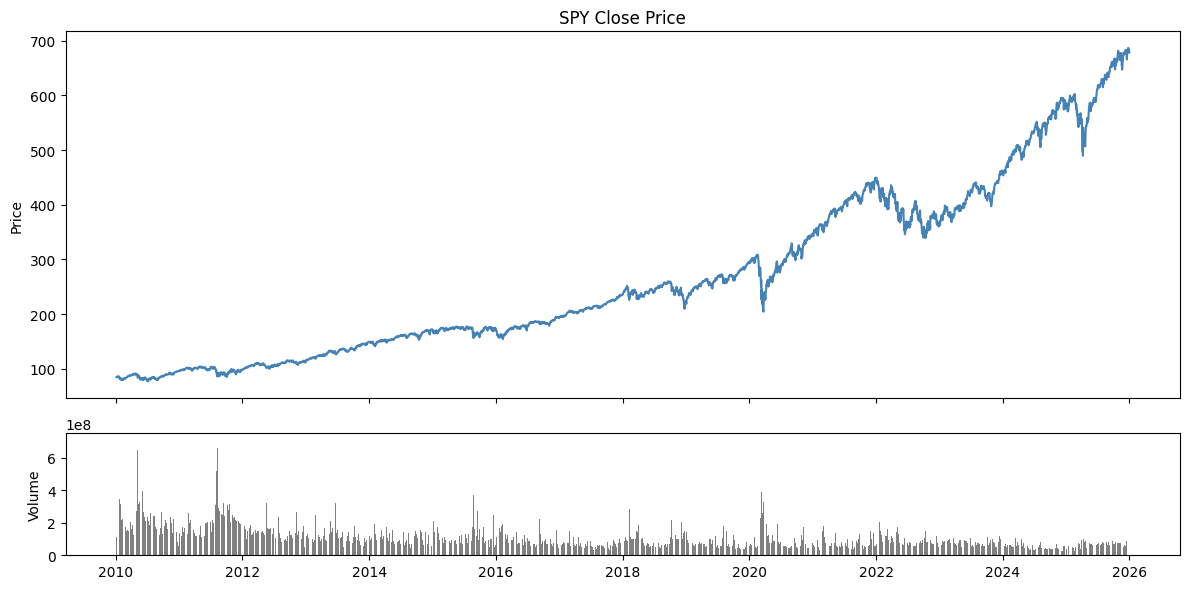

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(data.index, data['Close'], color='steelblue')
axes[0].set_title(f"{ticker} Close Price")
axes[0].set_ylabel("Price")

axes[1].bar(data.index, data['Volume'], color='gray', width=1)
axes[1].set_ylabel("Volume")

plt.tight_layout()
plt.show()

In [13]:
data.to_csv("spy_data.csv")

from google.colab import files
files.download("spy_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Linear Regression for Stock Price Prediction

This section demonstrates a simple linear regression model to predict the next day's closing price based on the previous day's closing price. This is a basic example to illustrate the process of building a predictive model.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create a lagged feature: 'Close' price of the previous day
data['Close_lag1'] = data['Close'].shift(1)

# Drop rows with NaN values created by the lag
data_reg = data.dropna()

# Define features (X) and target (y)
X = data_reg[['Close_lag1']]
y = data_reg['Close']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, {y_test.shape}")

Training data shape: (3218, 1), (3218,)
Testing data shape: (805, 1), (805,)


### Model Training and Evaluation

We will now train a `LinearRegression` model and evaluate its performance using Mean Squared Error (MSE) and R-squared ($R^2$) on the test set.

In [15]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

print(f"Model Coefficients: {model.coef_[0]:.2f}")
print(f"Model Intercept: {model.intercept_:.2f}")

Mean Squared Error (MSE): 9.79
R-squared (R2): 1.00
Model Coefficients: 1.00
Model Intercept: 0.00


### Visualization of Predictions

To visually assess the model's performance, we'll plot the actual closing prices against the predicted closing prices for the test set.

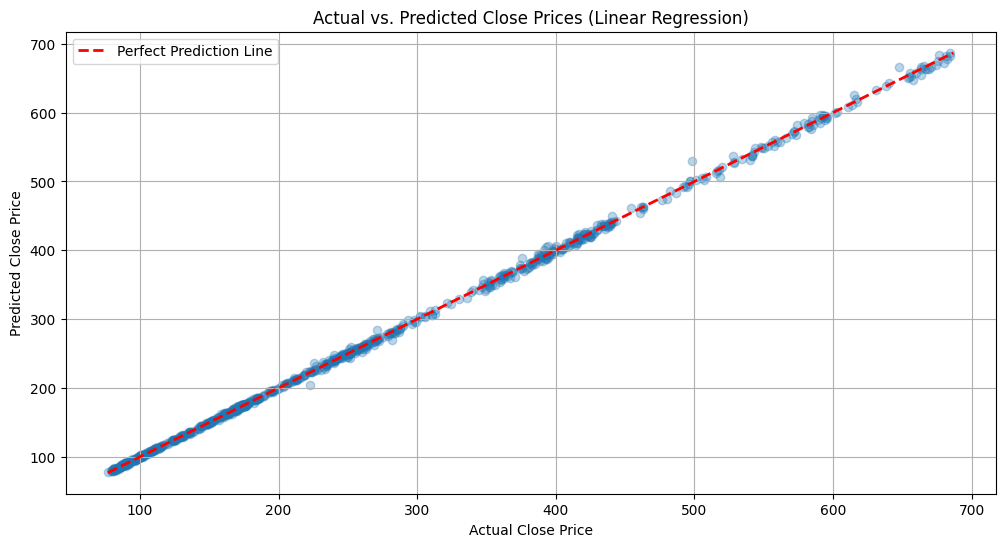

In [16]:
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.title('Actual vs. Predicted Close Prices (Linear Regression)')
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Price')
plt.legend()
plt.grid(True)
plt.show()

## 8. Summary and Statistics of the Dataset

This section provides a comprehensive statistical overview of the dataset, including its structure, descriptive metrics, and relationships between variables.

In [17]:
print("Dataset Info:")
data.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4024 entries, 2010-01-04 to 2025-12-31
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Close       4024 non-null   float64
 1   High        4024 non-null   float64
 2   Low         4024 non-null   float64
 3   Open        4024 non-null   float64
 4   Volume      4024 non-null   int64  
 5   Close_lag1  4023 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 220.1 KB


In [18]:
print("\nDescriptive Statistics:")
display(data.describe())


Descriptive Statistics:


Price,Close,High,Low,Open,Volume,Close_lag1
count,4024.000000,4024.000000,4024.000000,4024.000000,4.024000e+03,4023.000000
mean,267.381333,268.767389,265.767215,267.333626,1.093601e+08,267.279187
std,155.196677,155.963036,154.291703,155.177997,6.796507e+07,155.080627
min,76.950607,77.869197,76.144963,77.635787,2.027000e+07,76.950607
25%,145.848522,146.342603,145.514667,145.947770,6.523638e+07,145.845955
50%,227.204430,230.529505,225.512813,227.413137,8.943210e+07,227.113617
75%,385.398270,387.617707,382.685095,384.862583,1.328817e+08,385.309418
max,686.730530,688.003728,685.626408,686.989161,7.178287e+08,686.730530


In [19]:
print("\nMissing Values:")
print(data.isna().sum())


Missing Values:
Price
Close         0
High          0
Low           0
Open          0
Volume        0
Close_lag1    1
dtype: int64


In [20]:
print("\nSkewness:")
print(data.skew(numeric_only=True))


Skewness:
Price
Close         0.823841
High          0.820687
Low           0.826767
Open          0.824235
Volume        2.494788
Close_lag1    0.823246
dtype: float64


In [21]:
print("\nKurtosis:")
print(data.kurt(numeric_only=True))


Kurtosis:
Price
Close         -0.272276
High          -0.282533
Low           -0.261467
Open          -0.270407
Volume        10.892208
Close_lag1    -0.273522
dtype: float64


In [22]:
print("\nCorrelation Matrix:")
display(data.corr(numeric_only=True))


Correlation Matrix:


Price,Close,High,Low,Open,Volume,Close_lag1
Price,,,,,,
Close,1.000000,0.999921,0.999924,0.999859,-0.490997,0.999779
High,0.999921,1.000000,0.999870,0.999931,-0.487326,0.999875
Low,0.999924,0.999870,1.000000,0.999923,-0.493665,0.999839
Open,0.999859,0.999931,0.999923,1.000000,-0.489870,0.999913
Volume,-0.490997,-0.487326,-0.493665,-0.489870,1.000000,-0.488666
Close_lag1,0.999779,0.999875,0.999839,0.999913,-0.488666,1.000000
